In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf
import ipywidgets
from ipywidgets import interact

In [8]:
df=pd.read_csv("matches.csv")

print(f"Dataset Shape: {df.shape}")

Dataset Shape: (756, 18)


In [9]:
df.columns

Index(['id', 'Season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

In [10]:
#id unique num given to row
#season ipl season a match was played
#city city match was played
#date
#team1,team2: the teams who played each other
#toss winner: team who won the toss
#toss decision: whether the winning team chose field or bat
#result column: result of the match
#dl applied: whether the dl is applied 1==>True, is applied; 0==> False
#------>dl stands for Duckworth Lewis Stern. It's a formula to calculate the target 
#------>score for the team batting second in a limited overs match
#------>such as if the match is interrupted by weather or other circumstance
#rusults
#winner
#dl applied
#win_by_runs,win_by_wickets: margin of win
#player of the match (from winning or from loosing, can be either)
#venue: name of staduim
#umpire1,2,and 3: name of umpires

In [11]:
#Indian Premier League (IPL) is a professional 20-20 cricket league in India
#it plays between March and May
#each team represents different cities  
#it is the most attended cricket league in the world

### Data is from different IPL matches played in different seasons from 2008 to 2019  
Qs:  
>staduim where max matches were played  
>how team performs in different seasons  
>wich team wins most against a particular team  

In [12]:
df['city']=df['city'].replace({'Bangalore':'Bangaluru'})

cities=set(df['city'].unique())
print(cities)

{'Rajkot', 'Cuttack', 'East London', 'Visakhapatnam', 'Bloemfontein', 'Kolkata', 'Mumbai', 'Durban', 'Kochi', 'Pune', 'Bangaluru', 'Indore', 'Ranchi', 'Raipur', 'Sharjah', 'Johannesburg', 'Abu Dhabi', 'Kimberley', 'Chennai', 'Port Elizabeth', 'Nagpur', 'Ahmedabad', 'Dharamsala', 'Jaipur', 'Kanpur', 'Mohali', 'Delhi', nan, 'Cape Town', 'Centurion', 'Hyderabad', 'Bengaluru', 'Chandigarh'}


In [13]:
for col in ['team1','Season','city','venue']:
    print(f"total number of {col}s: {df[col].nunique()}".title())

Total Number Of Team1S: 15
Total Number Of Seasons: 12
Total Number Of Citys: 32
Total Number Of Venues: 41


In [14]:
ump_1=df['umpire1'].unique()
ump_2=df['umpire2'].unique()
ump_3=df['umpire3'].unique()
ump=set(ump_1).intersection(set(ump_2))
ump=ump.intersection(set(ump_3))
print(f"number of umpires: {len(ump)}".title())
print(f"Names of Umpires: {ump}")

Number Of Umpires: 20
Names of Umpires: {'Yeshwant Barde', 'Rod Tucker', 'Nigel Llong', 'C Shamshuddin', 'S Ravi', 'Ulhas Gandhe', 'Vineet Kulkarni', 'Nitin Menon', 'A Nanda Kishore', 'Nanda Kishore', 'Anil Dandekar', 'Ian Gould', 'Bruce Oxenford', 'KN Ananthapadmanabhan', 'Anil Chaudhary', 'Chris Gaffaney', nan, 'K Ananthapadmanabhan', 'O Nandan', 'Kumar Dharmasena'}


In [15]:
df.loc[(df['umpire1'].isnull())&
       (df['umpire2'].isnull())&
        (df['umpire3'].isnull())][['date','team1','team2','winner','umpire1','umpire2','umpire3']]

,date,team1,team2,winner,umpire1,umpire2,umpire3
4,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,NaN,NaN,NaN
753,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,NaN,NaN,NaN


Homework: how can these not have umpires?  
# ---------------------------------------

## Explore Best Players

In [16]:
print(f"Number of players who've won Player_of_the_Match: {df['player_of_match'].nunique()}")
df['player_of_match'].value_counts().sort_values(ascending=False).head(10)

Number of players who've won Player_of_the_Match: 226


player_of_match
CH Gayle          21
AB de Villiers    20
RG Sharma         17
MS Dhoni          17
DA Warner         17
YK Pathan         16
SR Watson         15
SK Raina          14
G Gambhir         13
MEK Hussey        12
Name: count, dtype: int64

In [17]:
df.loc[(df['player_of_match']=='CH Gayle')][['date','team1','team2','winner']].reset_index(drop=True)

,date,team1,team2,winner
0,18-04-2017,Royal Challengers Bangalore,Gujarat Lions,Royal Challengers Bangalore
1,21-04-2009,Kings XI Punjab,Kolkata Knight Riders,Kolkata Knight Riders
2,22-04-2011,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore
3,06-05-2011,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore
4,08-05-2011,Kochi Tuskers Kerala,Royal Challengers Bangalore,Royal Challengers Bangalore
5,14-05-2011,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore
6,22-05-2011,Chennai Super Kings,Royal Challengers Bangalore,Royal Challengers Bangalore
7,27-05-2011,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore
8,17-04-2012,Pune Warriors,Royal Challengers Bangalore,Royal Challengers Bangalore
9,20-04-2012,Kings XI Punjab,Royal Challengers Bangalore,Royal Challengers Bangalore


In [18]:
def before_after_CG(after=True):
    """a functionto examine Chris Gayle's teams before and after he was traided"""
    teams=['Kings XI Punjab','Royal Challengers Bangalore']
    seasons_after_gayle=['IPL-2018','IPL-2019']
    print('Matches won before Gayle moved to Kings XI Punjab')
    display(df.loc[(df['winner'].isin(teams))&~(df['Season'].isin(seasons_after_gayle))]['winner'].value_counts())
    print('. . '*8,'\n','Matches won after Gayle moved to Kings XI Punjab')
    display(df.loc[(df['winner'].isin(teams))&(df['Season'].isin(seasons_after_gayle))]['winner'].value_counts())
    print('. . '*8,'\n','Wickets in matches won after Gayle moved to Kings XI Punjab')
    display(df.loc[(df['winner'].isin(teams))&(df['Season'].isin(seasons_after_gayle))].groupby('winner',as_index=False)[['win_by_runs','win_by_wickets']].sum())

before_after_CG()

    

Matches won before Gayle moved to Kings XI Punjab


winner
Royal Challengers Bangalore    73
Kings XI Punjab                70
Name: count, dtype: int64

. . . . . . . . . . . . . . . .  
 Matches won after Gayle moved to Kings XI Punjab


winner
Kings XI Punjab                12
Royal Challengers Bangalore    11
Name: count, dtype: int64

. . . . . . . . . . . . . . . .  
 Wickets in matches won after Gayle moved to Kings XI Punjab


,winner,win_by_runs,win_by_wickets
0,Kings XI Punjab,63,41
1,Royal Challengers Bangalore,56,37


In [19]:
seasons=['IPL-2018','IPL-2019']
teams=['Kings XI Punjab','Royal Challengers Bangalore']
matches_rcb_vc_kxp=df.loc[(df['team1'].isin(teams))&
                          (df['team2'].isin(teams))&
                           (df['Season'].isin(seasons))].reset_index(drop=True)
matches_rcb_vc_kxp[['Season','team1','team2','winner']]

,Season,team1,team2,winner
0,IPL-2018,Kings XI Punjab,Royal Challengers Bangalore,Royal Challengers Bangalore
1,IPL-2018,Kings XI Punjab,Royal Challengers Bangalore,Royal Challengers Bangalore
2,IPL-2019,Kings XI Punjab,Royal Challengers Bangalore,Royal Challengers Bangalore
3,IPL-2019,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore


In [20]:
#this is different than the assignment because it includes player_of_match from team1 and team2
two_teams=pd.concat([df[['team1','Season','player_of_match']]
                     .copy().rename(columns={'team1':'team'}),
                    df[['team2','Season','player_of_match']]
                    .copy().rename(columns={'team2':'team'})],
)



@interact
def best_players(season=list(two_teams['Season'].value_counts()
                             .sort_values(ascending=False).index),
                 team=list(two_teams['team']
                           .value_counts().index),
):
    a=two_teams.loc[(two_teams['Season']==season)&
                    (two_teams['team']==team)]
    return a['player_of_match'].value_counts()


interactive(children=(Dropdown(description='season', options=('IPL-2013', 'IPL-2012', 'IPL-2011', 'IPL-2010', …

### Biggest Matches

,win_by_runs,win_by_wickets
count,756.000000,756.000000
mean,13.283069,3.350529
std,23.471144,3.387963
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,4.000000
75%,19.000000,6.000000
max,146.000000,10.000000


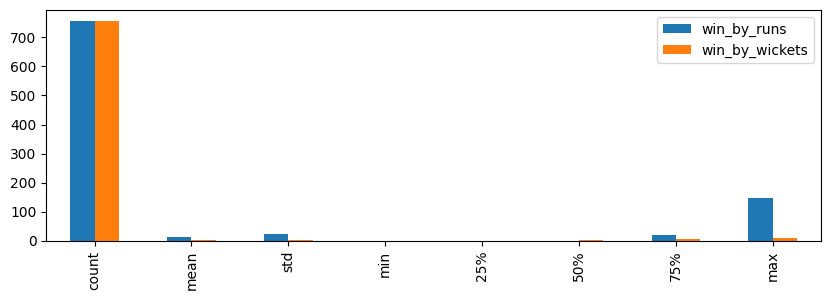

In [21]:
display(df[['win_by_runs','win_by_wickets']].describe())
plt.rcParams['figure.figsize']=(10,3)
df[['win_by_runs','win_by_wickets']].describe().plot(kind='bar')
plt.show()

In [22]:
#examine the game with max 146 runs as above
df.loc[df['win_by_runs']==146][['Season',
                                'team1',
                                'team2',
                                'winner',
                                'player_of_match',
]].reset_index(drop=True)

,Season,team1,team2,winner,player_of_match
0,IPL-2017,Mumbai Indians,Delhi Daredevils,Mumbai Indians,LMP Simmons


In [23]:
#examine team(s) who won by 10 wickets
df.loc[df['win_by_wickets']==10][['Season',
                                  'team1',
                                  'team2',
                                  'winner',
                                  'player_of_match',
]].reset_index(drop=True)

,Season,team1,team2,winner,player_of_match
0,IPL-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,CA Lynn
1,IPL-2017,Delhi Daredevils,Kings XI Punjab,Kings XI Punjab,Sandeep Sharma
2,IPL-2008,Mumbai Indians,Deccan Chargers,Deccan Chargers,AC Gilchrist
3,IPL-2009,Kings XI Punjab,Delhi Daredevils,Delhi Daredevils,DL Vettori
4,IPL-2010,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,JH Kallis
5,IPL-2011,Mumbai Indians,Rajasthan Royals,Rajasthan Royals,SR Watson
6,IPL-2012,Rajasthan Royals,Mumbai Indians,Mumbai Indians,DR Smith
7,IPL-2013,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,MEK Hussey
8,IPL-2015,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,VR Aaron
9,IPL-2016,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,B Kumar


In [24]:
df.loc[(df['winner']=='Royal Challengers Bangalore')&
       ( (df['win_by_wickets']>=7)|(df['win_by_runs']>=100) )]

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
142,143,IPL-2009,Johannesburg,03-05-2009,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,9,JH Kallis,New Wanderers Stadium,RE Koertzen,TH Wijewardene,NaN
166,167,IPL-2009,Johannesburg,19-05-2009,Delhi Daredevils,Royal Challengers Bangalore,Delhi Daredevils,bat,normal,0,Royal Challengers Bangalore,0,7,JH Kallis,New Wanderers Stadium,IL Howell,RB Tiffin,NaN
180,181,IPL-2010,Bangaluru,16-03-2010,Kings XI Punjab,Royal Challengers Bangalore,Kings XI Punjab,bat,normal,0,Royal Challengers Bangalore,0,8,JH Kallis,M Chinnaswamy Stadium,S Das,DJ Harper,NaN
183,184,IPL-2010,Bangaluru,18-03-2010,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,10,JH Kallis,M Chinnaswamy Stadium,K Hariharan,DJ Harper,NaN
187,188,IPL-2010,Mumbai,20-03-2010,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,7,JH Kallis,Brabourne Stadium,HDPK Dharmasena,SS Hazare,NaN
216,217,IPL-2010,Bangaluru,10-04-2010,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,7,R Vinay Kumar,M Chinnaswamy Stadium,K Hariharan,DJ Harper,NaN
232,233,IPL-2010,Mumbai,24-04-2010,Deccan Chargers,Royal Challengers Bangalore,Deccan Chargers,bat,normal,0,Royal Challengers Bangalore,0,9,A Kumble,Dr DY Patil Sports Academy,RE Koertzen,SJA Taufel,NaN
257,258,IPL-2011,Kolkata,22-04-2011,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,9,CH Gayle,Eden Gardens,SS Hazare,RB Tiffin,NaN
282,283,IPL-2011,Bangaluru,08-05-2011,Kochi Tuskers Kerala,Royal Challengers Bangalore,Kochi Tuskers Kerala,bat,normal,0,Royal Challengers Bangalore,0,9,CH Gayle,M Chinnaswamy Stadium,Aleem Dar,SS Hazare,NaN
287,288,IPL-2011,Jaipur,11-05-2011,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,9,S Aravind,Sawai Mansingh Stadium,HDPK Dharmasena,K Hariharan,NaN


### top 3 teams  
>Royal Challengers Bangalore  
>Mumbai Indians  
>Chennai Super Kings  

In [25]:
df['team1'].unique()

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants',
       'Delhi Capitals'], dtype=object)

In [26]:
mi=df.loc[(df['team1']=='Mumbai Indians')|(df['team2']=='Mumbai Indians')]
csk=df.loc[(df['team1']=='Chennai Super Kings')|(df['team2']=='Chennai Super Kings')]
rcb=df.loc[(df['team1']=='Royal Challengers Bangalore')|(df['team2']=='Royal Challengers Bangalore')]
data=pd.concat([mi,csk,rcb])
data=data.loc[data['winner'].isin(['Royal Challengers Bangalore','Mumbai Indians','Chennai Super Kings'])]
data[['Season',
      'winner',
      'win_by_runs',
      'win_by_wickets',
      'player_of_match',
]].groupby(['winner'])[['win_by_runs','win_by_wickets']].agg(['min','mean','max','sum','count'
                                                              ]).style.background_gradient(cmap='inferno')

In [27]:
df['result'].value_counts()

result
normal       743
tie            9
no result      4
Name: count, dtype: int64

In [28]:

total_obs = df.shape[0]
for k,v in {'normal':df.loc[df['result']=='normal'] ,
            'tie': df.loc[df['result']=='tie'] , 
            'no result':df.loc[df['result']=='no result']
            }.items():
    print(f"Percentage of matches where result is '{k}': {int(round(v.shape[0]/total_obs,2)*100)}%")

Percentage of matches where result is 'normal': 98%
Percentage of matches where result is 'tie': 1%
Percentage of matches where result is 'no result': 1%


In [29]:
print(f'games where it was a tie: ')
display(df.loc[df['result']=='tie'][['date','team1','team2']].reset_index(drop=True))
print(f'games where there was no result: ')
display(df.loc[df['result']=='no result'][['date','team1','team2']].reset_index(drop=True))

games where it was a tie: 


,date,team1,team2
0,29-04-2017,Gujarat Lions,Mumbai Indians
1,23-04-2009,Rajasthan Royals,Kolkata Knight Riders
2,21-03-2010,Kings XI Punjab,Chennai Super Kings
3,07-04-2013,Royal Challengers Bangalore,Sunrisers Hyderabad
4,16-04-2013,Delhi Daredevils,Royal Challengers Bangalore
5,29-04-2014,Rajasthan Royals,Kolkata Knight Riders
6,21-04-2015,Rajasthan Royals,Kings XI Punjab
7,30-03-2019,Kolkata Knight Riders,Delhi Capitals
8,02-05-2019,Mumbai Indians,Sunrisers Hyderabad


games where there was no result: 


,date,team1,team2
0,21-05-2011,Delhi Daredevils,Pune Warriors
1,29-04-2015,Royal Challengers Bangalore,Rajasthan Royals
2,17-05-2015,Delhi Daredevils,Royal Challengers Bangalore
3,30-04-2019,Royal Challengers Bangalore,Rajasthan Royals


C:\Users\user\AppData\Local\Temp\ipykernel_14716\2683421326.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Season'].sort_values(),palette='copper')


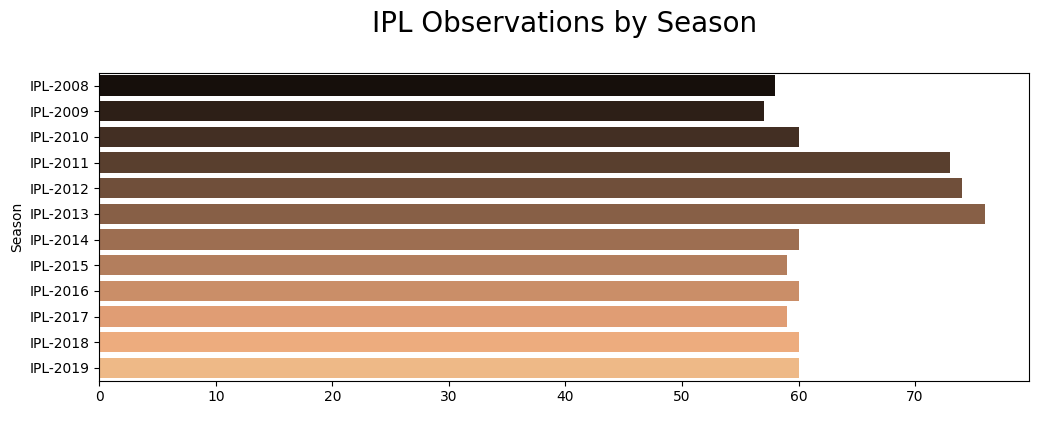

In [30]:
plt.rcParams['figure.figsize']=(12,4)
sns.countplot(y=df['Season'].sort_values(),palette='copper')
plt.title('IPL Observations by Season\n',fontsize = 20)
plt.xlabel(' ')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_14716\405546910.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=teams.sort_values(),palette='Wistia')


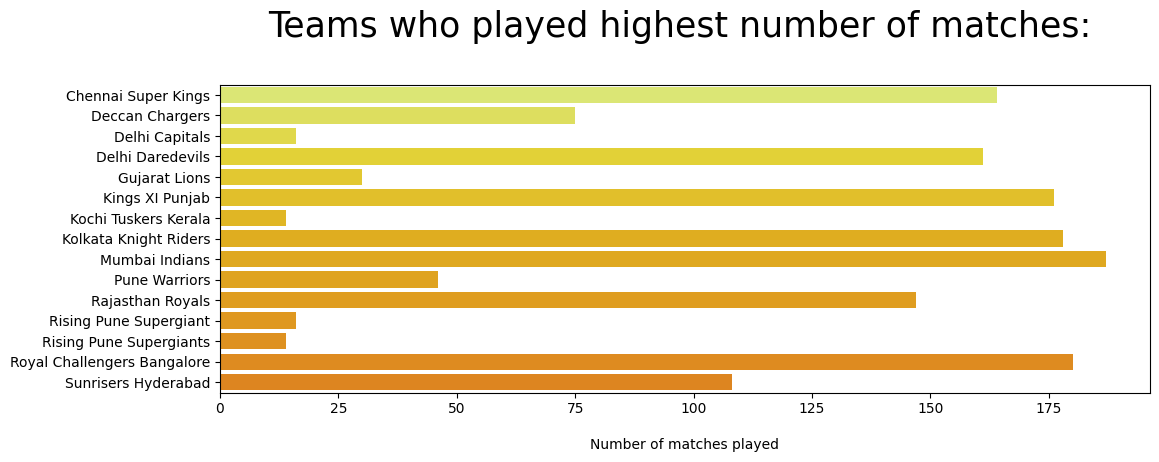

In [31]:
teams=pd.concat([ df['team1'].rename({'team1':'team'}),df['team2'].rename({'team2':'team'})])


plt.rcParams['figure.figsize']=(12,4)
plt.title(f'Teams who played highest number of matches: \n',fontsize=25)
sns.countplot(y=teams.sort_values(),palette='Wistia')
plt.ylabel('')
plt.xlabel('\nNumber of matches played')
plt.show()

In [32]:
def won_most_seasons():
    season_winner_count=df[                               .groupby(['Season','winner'],as_index=False)
    return season_winner_count
won_most_seasons()

SyntaxError: invalid syntax (80987316.py, line 2)

Homework:   find reason behind huge popularity of IPL seasons 2011,2012,and 2013  
# ---------------------------------------

C:\Users\user\AppData\Local\Temp\ipykernel_23060\1637527735.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df['venue'].value_counts().head(15).index,


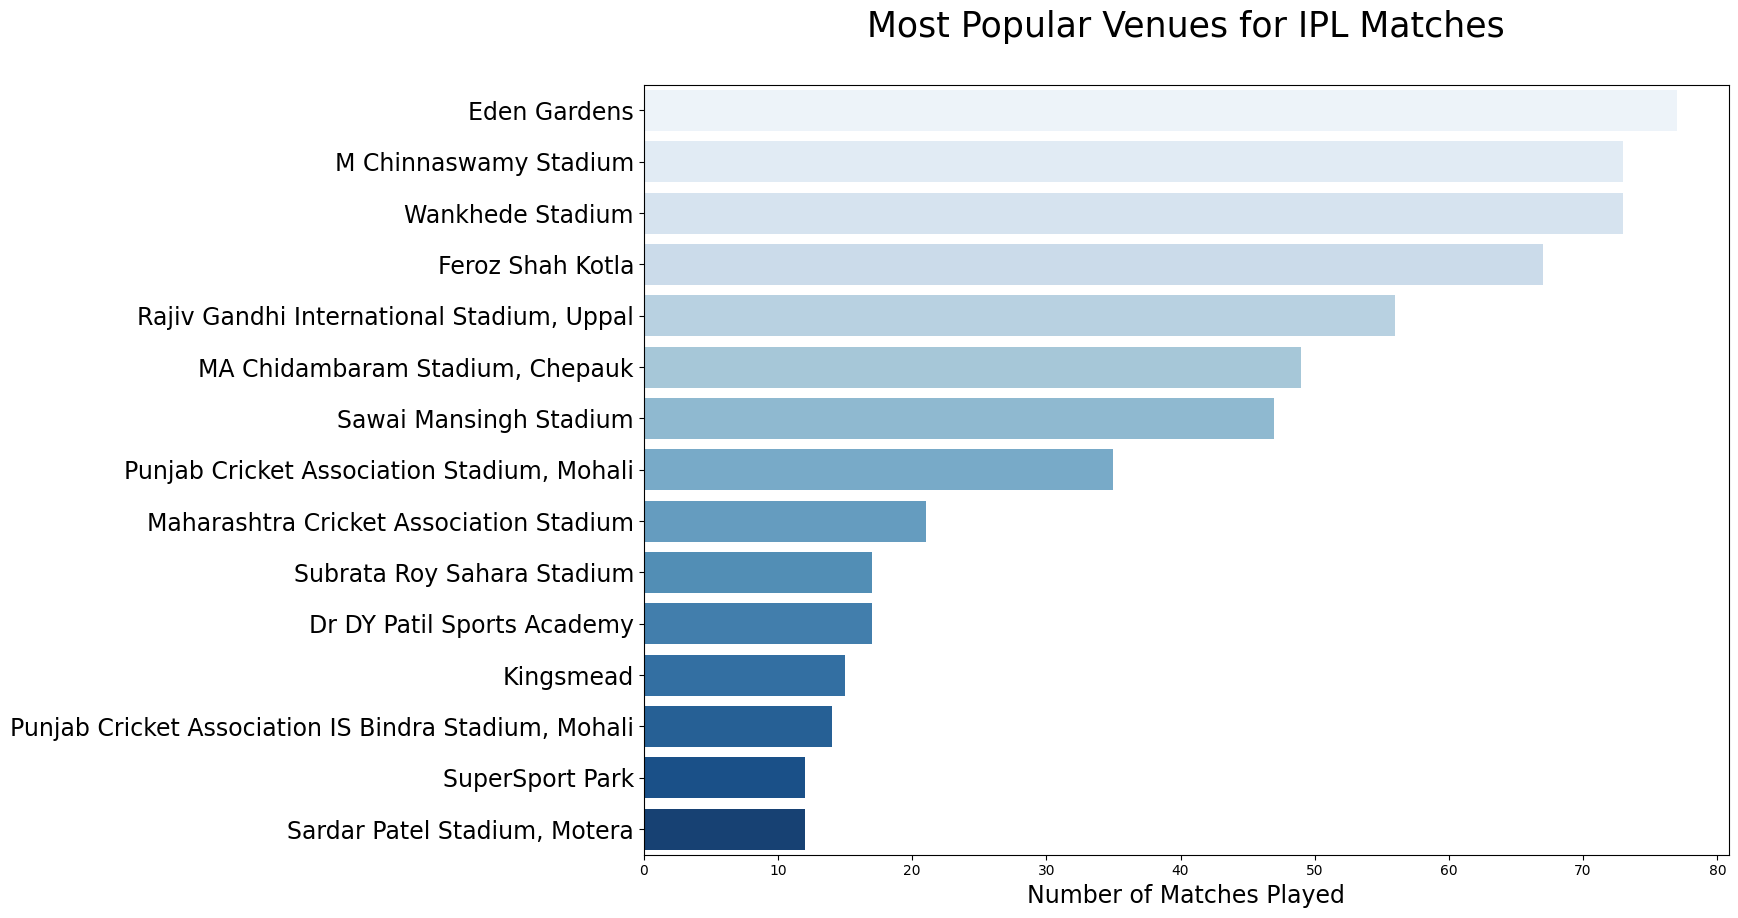

In [ ]:
plt.rcParams['figure.figsize']=(14,10)
sns.barplot(y=df['venue'].value_counts().head(15).index,
            x=df['venue'].value_counts().head(15).values,
            palette='Blues')
plt.title('Most Popular Venues for IPL Matches\n',fontsize=25)
plt.ylabel('')
plt.yticks(fontsize=17)
plt.xlabel('Number of Matches Played',fontsize=17)
plt.show()

In [ ]:
@interact
def city(season=list(df['Season'].value_counts().index)):
    cities=df.groupby(['Season','city'])['id'].agg('count').reset_index()
    cities.rename(columns={'id':'count'},inplace=True)
    print(f'Number of matches played in {season} by city.')
    return cities.loc[
        (cities['Season']==season)].sort_values(by='count',
         ascending=False).reset_index(drop=True).style.background_gradient(cmap='Greens')



interactive(children=(Dropdown(description='season', options=('IPL-2013', 'IPL-2012', 'IPL-2011', 'IPL-2010', …

In [ ]:
df['winner'].value_counts()

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

In [ ]:
same=df.loc[(df['toss_winner']==df['winner'])].shape[0]
not_same=df.loc[(df['toss_winner']!=df['winner'])].shape[0]
total=df.shape[0]
print(f"Percent of matches where toss winner isn't the winner: {round(round(not_same/total,4)*100,2)}%")
print(f"Percent of matches where toss winner isn't the winner: {round(round(same/total,4)*100,2)}%")

Percent of matches where toss winner isn't the winner: 48.02%
Percent of matches where toss winner isn't the winner: 51.98%


In [ ]:
@interact
def win_toss(winner=list(df['winner'].value_counts().index)):
    return pd.DataFrame(pd.crosstab(df['toss_winner'],df['winner'])[winner]).sort_values(by=winner,ascending=False).style.background_gradient(cmap='copper')

interactive(children=(Dropdown(description='winner', options=('Mumbai Indians', 'Chennai Super Kings', 'Kolkat…

In [ ]:
@interact
def teams_in_city(city=list(df['city'].value_counts().index)):
    x=df[['city','winner']]
    x=x.loc[(x['city']==city)]
    print(f"Teams that won in {city}")
    return pd.DataFrame(x['winner'].value_counts()).style.background_gradient(cmap='autumn')

interactive(children=(Dropdown(description='city', options=('Mumbai', 'Kolkata', 'Delhi', 'Bangaluru', 'Hydera…

In [ ]:
teams=set(df['team1'].tolist())|set(df['team2'].tolist())
@interact
def teams_winning_location(team=list(teams)):
    x=df[['winner','city']]
    x=x.loc[(x['winner']==team)]
    print(f"{team} wins by city")
    return pd.DataFrame(x['city'].value_counts()).style.background_gradient(cmap='Oranges')

interactive(children=(Dropdown(description='team', options=('Mumbai Indians', 'Rising Pune Supergiant', 'Gujar…

### as we see above, home field seems to have an effect

toss decision  

In [ ]:
df['toss_decision'].value_counts()

toss_decision
field    463
bat      293
Name: count, dtype: int64

In [ ]:
field=df.loc[(df['toss_decision']=='field')].shape[0]
bat=df.loc[(df['toss_decision']=='bat')].shape[0]
total=df.shape[0]
def print_pct(num,den,val_name):
    print(f"Percentage of matches where toss_decision is {val_name}: {round(num/den*100,2)}%")

print_pct(field,total,'feild')
print_pct(bat,total,'bat')

Percentage of matches where toss_decision is feild: 61.24%
Percentage of matches where toss_decision is bat: 38.76%


C:\Users\user\AppData\Local\Temp\ipykernel_23060\21553454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['toss_winner'],


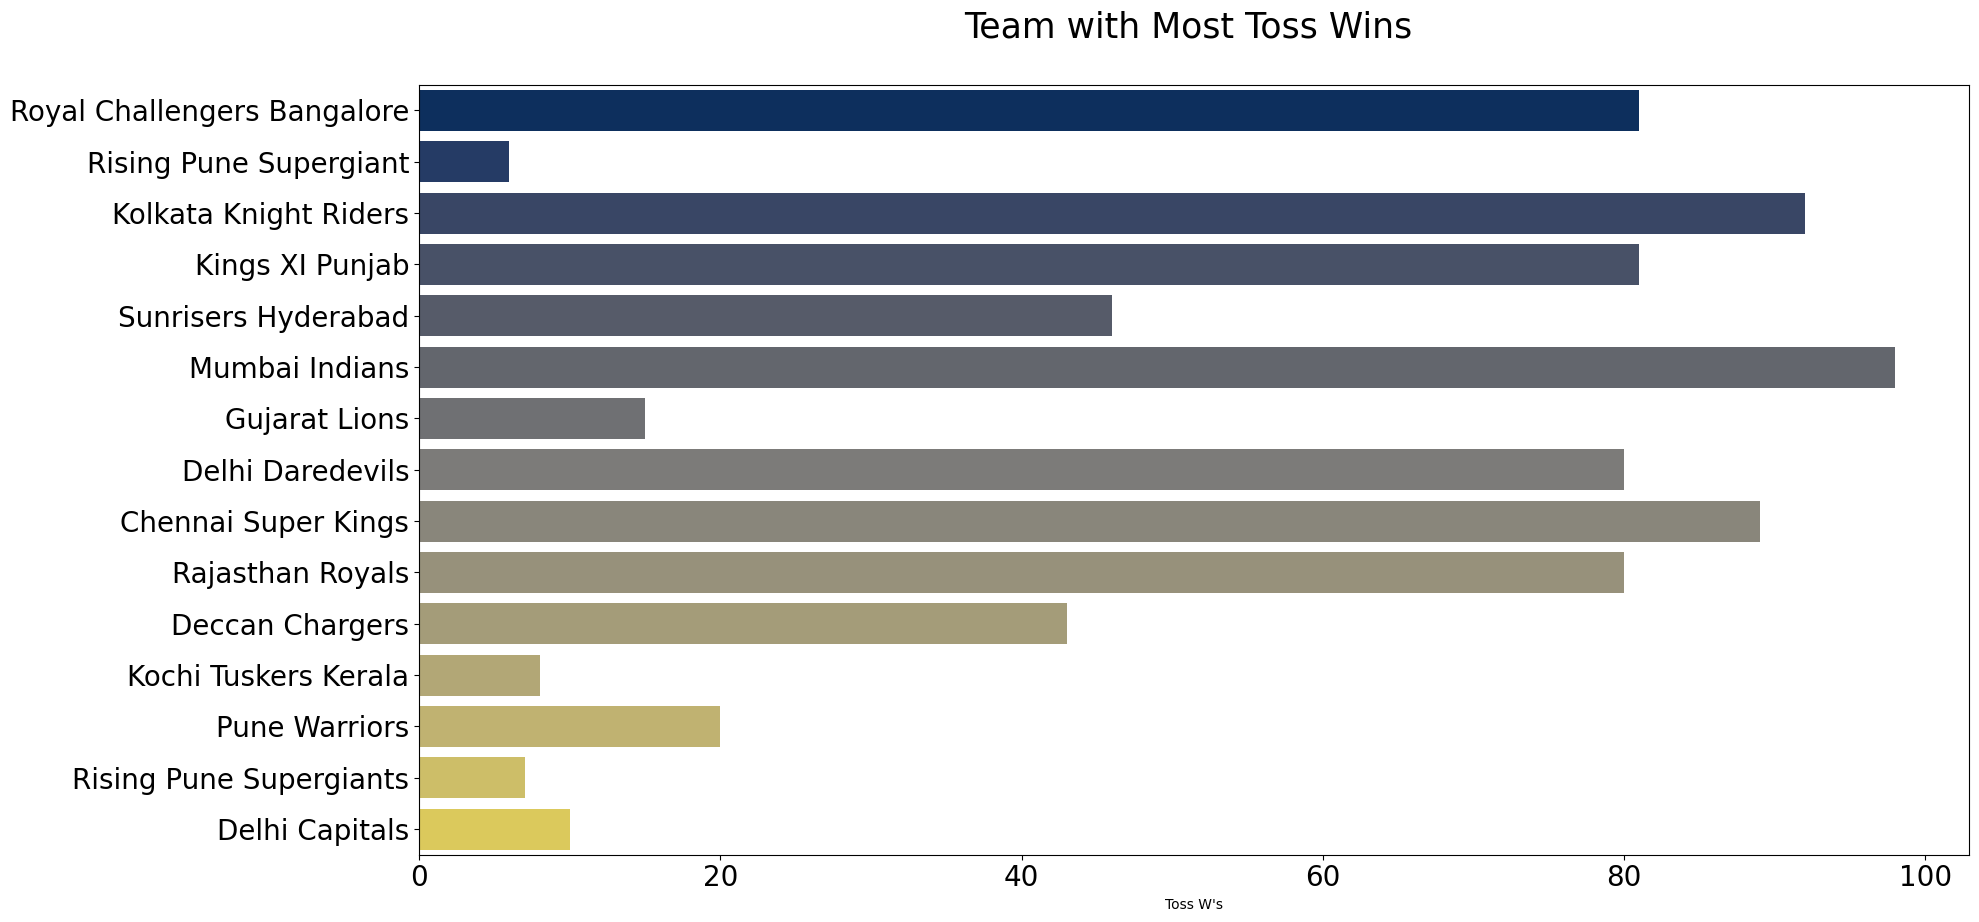

In [ ]:
#num times each team won
plt.rcParams['figure.figsize']=(20,10)
sns.countplot(y=df['toss_winner'],
              palette='cividis')
plt.title(f"Team with Most Toss Wins \n",fontsize=25)
plt.ylabel('')
plt.yticks(fontsize=20)
plt.xlabel("Toss W's")
plt.xticks(fontsize=20)
plt.show()

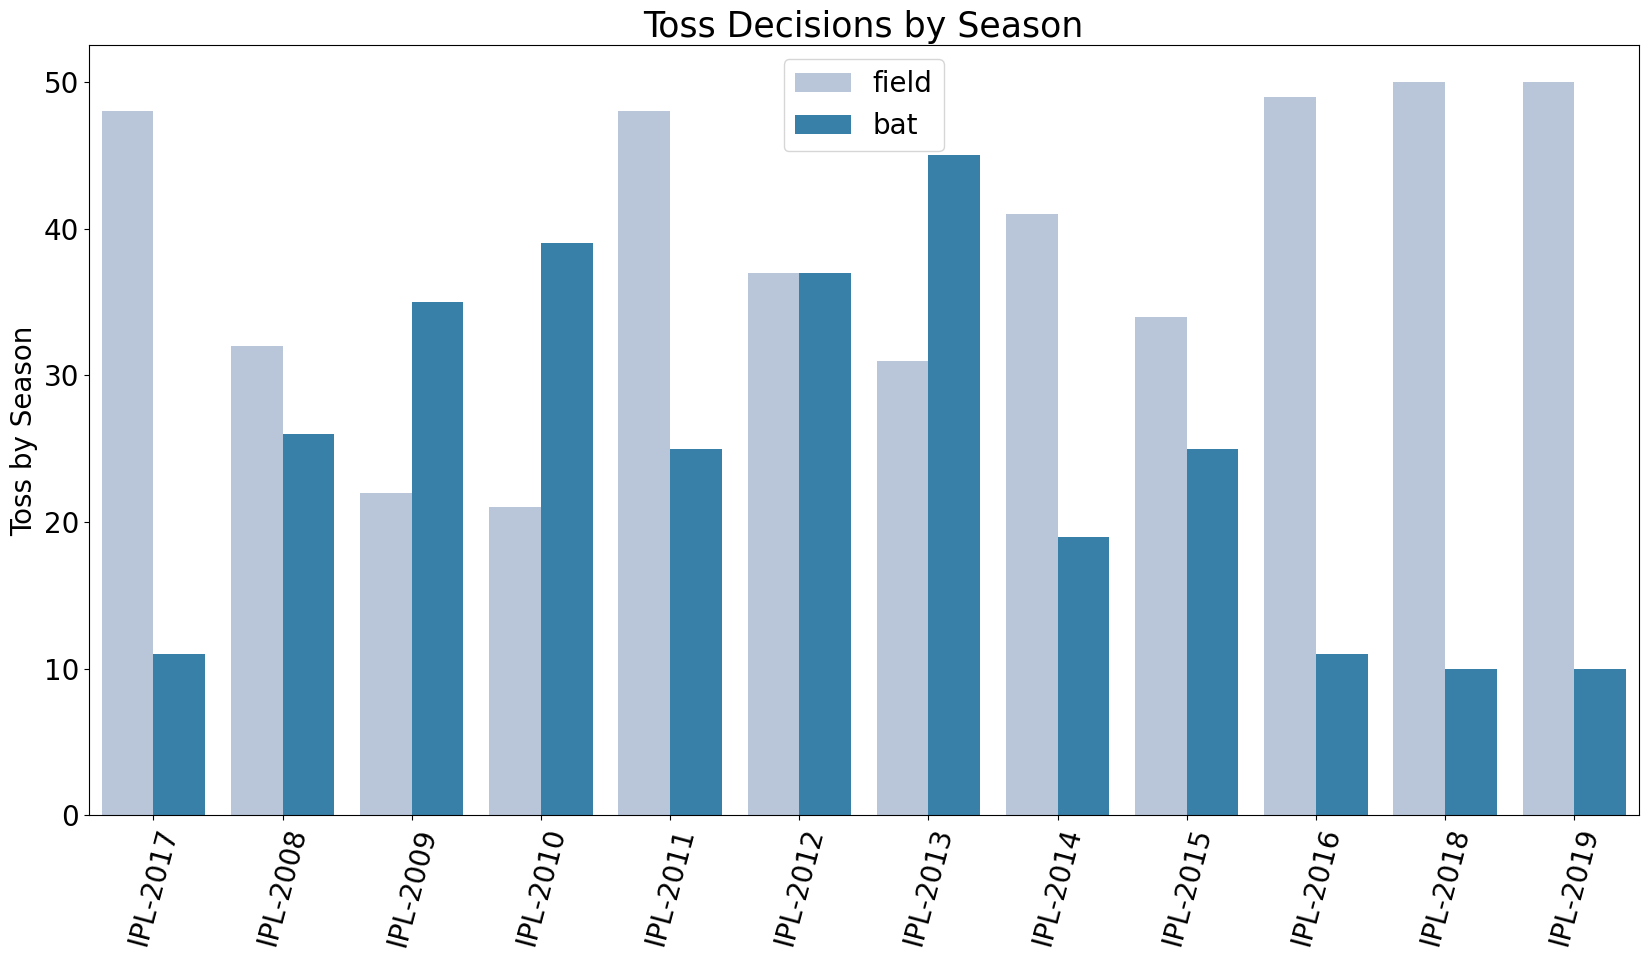

In [ ]:
plt.rcParams['figure.figsize']=(20,10)
x=df['Season'].sort_values(ascending=True)
sns.countplot(x=x, 
              hue=df['toss_decision'],
              palette='PuBu')
plt.xlabel('')
plt.ylabel('Toss by Season',fontsize=20)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20,rotation=75)
plt.legend(fontsize=20)
plt.title('Toss Decisions by Season',fontsize=25)
plt.show()

In [ ]:
@interact
def toss_decision(team=list(df['toss_winner'].value_counts().index),
                  season=list(df['Season'].value_counts().index)):
    x=df.loc[(df['toss_winner']==team)&(df['Season']==season)]
    print('Toss Winners:\nTeams by Season')
    return x['toss_decision'].value_counts()

interactive(children=(Dropdown(description='team', options=('Mumbai Indians', 'Kolkata Knight Riders', 'Chenna…

In [ ]:
@interact
def toss_decision(team=list(df['toss_winner'].value_counts().index)):
    x=df.loc[(df['toss_winner']==team)]
    print('Toss Winners')
    return x['toss_decision'].value_counts()

interactive(children=(Dropdown(description='team', options=('Mumbai Indians', 'Kolkata Knight Riders', 'Chenna…

In [ ]:
#pct where toss winner won game
win_toss_and_game=round(df.loc[(df['toss_winner']==df['winner'])].shape[0]/df.shape[0]*100,2)
print(f"Percent of matches where the toss winner won the match: {win_toss_and_game}%")

Percent of matches where the toss winner won the match: 51.98%


DL

In [ ]:
dl_applied_no=df.loc[(df['dl_applied']==0)].shape[0]
dl_applied_yes=df.loc[(df['dl_applied']==1)].shape[0]
total=df.shape[0]
def print_applied(num,den,val_name):
    print(f"Percentage where {val_name}: {round(num/den*100,2)}%")
print_applied(dl_applied_no,total,'DL was not applied')
print_applied(dl_applied_yes,total,'DL was applied')

Percentage where DL was not applied: 97.49%
Percentage where DL was applied: 2.51%


In [ ]:
def is_true(cond,cond_col,count_col):
    a=df.loc[(df[cond_col]==cond)]
    return a[count_col].value_counts()
is_true(1,'dl_applied','winner')

winner
Kolkata Knight Riders          4
Royal Challengers Bangalore    3
Kings XI Punjab                2
Chennai Super Kings            2
Delhi Daredevils               2
Sunrisers Hyderabad            2
Rising Pune Supergiants        2
Kochi Tuskers Kerala           1
Rajasthan Royals               1
Name: count, dtype: int64

In [ ]:
df.loc[(df['dl_applied']==1)][['Season','team1','team2','winner']].sort_values(by='Season').reset_index(drop=True)

,Season,team1,team2,winner
0,IPL-2008,Delhi Daredevils,Kings XI Punjab,Kings XI Punjab
1,IPL-2008,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings
2,IPL-2009,Kings XI Punjab,Delhi Daredevils,Delhi Daredevils
3,IPL-2009,Kings XI Punjab,Kolkata Knight Riders,Kolkata Knight Riders
4,IPL-2009,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings
5,IPL-2011,Chennai Super Kings,Kochi Tuskers Kerala,Kochi Tuskers Kerala
6,IPL-2011,Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders
7,IPL-2011,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore
8,IPL-2014,Delhi Daredevils,Sunrisers Hyderabad,Sunrisers Hyderabad
9,IPL-2015,Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad


key insights  
> summarized facts  
> unique teams  
> cities  
> best players  
> team performance  
> biggest matches  
> IPL locations  
> toss decision effect on match  
> dl  
> 

future exploration:   
> Time Series analysis  